# Car Listing Data Optimization: Performance Comparison
## Multiprocessing vs Polars vs Baseline (Pandas)

**Dataset:** `carlist_cleaned.csv` — 99,864 records, 12 features

**Objective:** Apply optimization techniques and compare performance across 4 metrics:
- Execution Time
- Memory Usage
- CPU Utilization
- Throughput (rows/second)

**Optimization Techniques:**
| Method | Description |
|--------|-------------|
| Baseline | Serial pandas — single-threaded, no parallelism |
| Multiprocessing | Python `multiprocessing.Pool` — splits data across CPU cores |
| Polars | Single-machine in-memory processing with multi-core parallelism and lazy evaluation |

**Task being benchmarked:** Load CSV → Filter → Feature Engineering → Aggregation

In [2]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import time
import threading
import tracemalloc
import os
import sys
import warnings
import polars as pl

import psutil
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, lit

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Configuration ──────────────────────────────────────────
CSV_PATH     = 'carlist_cleaned.csv'
N_WORKERS    = mp.cpu_count()
CURRENT_YEAR = 2026

print(f"Python     : {sys.version.split()[0]}")
print(f"Pandas     : {pd.__version__}")
print(f"PySpark    : {__import__('pyspark').__version__}")
print(f"CPU Cores  : {N_WORKERS}")
print(f"Dataset    : {CSV_PATH}")


Python     : 3.11.4
Pandas     : 3.0.2
PySpark    : 4.1.1
CPU Cores  : 16
Dataset    : carlist_cleaned.csv


## Utility: Metrics Collector

A reusable context manager that automatically measures 4 performance metrics for any code block:

| Metric | How it's measured |
|--------|------------------|
| **Execution Time** | `time.perf_counter()` — high-resolution timer |
| **Memory Usage** | `tracemalloc` + `psutil` RSS — peak memory in MB |
| **CPU Utilization** | `psutil.cpu_percent()` polled every 0.1s in a background thread |
| **Throughput** | Total rows ÷ elapsed time (rows/second) |

**Usage:**
```python
with MetricsCollector("MyMethod") as m:
    # your code here
print(m.elapsed_time, m.peak_memory_mb, m.avg_cpu_pct)


In [3]:

class MetricsCollector:
    """
    Context manager that records execution time, peak memory,
    CPU utilization, and throughput for a block of code.
    """

    def __init__(self, name):
        self.name = name
        self._cpu_samples = []
        self._stop_event = threading.Event()
        self._monitor_thread = None

    def _monitor_cpu(self):
        # Runs in a background thread — samples CPU every 0.1s
        while not self._stop_event.is_set():
            self._cpu_samples.append(psutil.cpu_percent(interval=0.1))

    def __enter__(self):
        self._process = psutil.Process()
        # Record baseline memory before execution
        self._mem_before = self._process.memory_info().rss / (1024 ** 2)
        tracemalloc.start()

        # Start CPU monitor thread
        self._stop_event.clear()
        self._cpu_samples = []
        self._monitor_thread = threading.Thread(target=self._monitor_cpu, daemon=True)
        self._monitor_thread.start()

        self._start_time = time.perf_counter()
        return self

    def __exit__(self, *args):
        # Stop the timer
        self.elapsed_time = time.perf_counter() - self._start_time

        # Stop CPU monitor thread
        self._stop_event.set()
        self._monitor_thread.join(timeout=1.0)

        # Get peak memory from tracemalloc (Python allocations)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # Also compare against RSS delta for native allocations (e.g. PySpark JVM)
        mem_after = self._process.memory_info().rss / (1024 ** 2)
        self.peak_memory_mb = max(peak / (1024 ** 2), mem_after - self._mem_before)

        # Summarise CPU samples
        self.avg_cpu_pct = np.mean(self._cpu_samples) if self._cpu_samples else 0.0
        self.max_cpu_pct = max(self._cpu_samples)     if self._cpu_samples else 0.0

    def throughput(self, n_rows):
        """Rows processed per second."""
        return n_rows / self.elapsed_time

# Stores benchmark results from all three methods for comparison later
results_log = {}
print("MetricsCollector ready.")


MetricsCollector ready.


## Section 1: Baseline — Serial Pandas Processing

The baseline uses standard **pandas** with no parallelism — everything runs sequentially on a single CPU core.

**Pipeline:**
1. Load CSV with `pd.read_csv()`
2. Filter rows: `mileage_km < 100,000`, condition = `Used`, `price_myr > 0`
3. Feature engineering: compute `price_per_km`, `car_age`, `price_per_year`
4. Aggregate by `state` — average price, car count, average mileage
5. Aggregate by `transmission` type
6. Find top 10 best-value cars (lowest price per km)


In [4]:
def baseline_analysis(csv_path):
    # ── Step 1: Load data ──────────────────────────────────
    df = pd.read_csv(csv_path)
    total_rows = len(df)

    # ── Step 2: Filter ─────────────────────────────────────
    df_f = df[
        (df['mileage_km'] < 100_000) &
        (df['condition'] == 'Used') &
        (df['price_myr'] > 0)
    ].copy()

    # ── Step 3: Feature Engineering ────────────────────────
    df_f['price_per_km']   = df_f['price_myr'] / (df_f['mileage_km'] + 1)
    df_f['car_age']        = CURRENT_YEAR - df_f['year']
    df_f['price_per_year'] = df_f['price_myr'] / (df_f['car_age'] + 1)

    # ── Step 4: Aggregate by state ─────────────────────────
    state_stats = df_f.groupby('state').agg(
        avg_price    = ('price_myr',  'mean'),
        car_count    = ('id',         'count'),
        avg_mileage  = ('mileage_km', 'mean'),
        median_price = ('price_myr',  'median')
    ).reset_index().sort_values('avg_price', ascending=False)

    # ── Step 5: Aggregate by transmission ─────────────────
    trans_stats = df_f.groupby('transmission').agg(
        avg_price   = ('price_myr',  'mean'),
        car_count   = ('id',         'count'),
        avg_mileage = ('mileage_km', 'mean')
    ).reset_index()

    # ── Step 6: Top 10 best value cars ────────────────────
    top_value = df_f.nsmallest(10, 'price_per_km')[
        ['title', 'state', 'price_myr', 'mileage_km', 'price_per_km']
    ]

    return total_rows, len(df_f), state_stats, trans_stats, top_value


In [5]:
print("=" * 60)
print("SECTION 1: BASELINE — Serial Pandas Processing")
print("=" * 60)

with MetricsCollector("Baseline") as m:
    total_rows, filtered_rows, state_stats, trans_stats, top_value = baseline_analysis(CSV_PATH)

# Store results for comparison later
results_log['Baseline'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}

# ── Print metrics ──────────────────────────────────────────
print(f"\nTotal rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")
print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} rows/s")

# ── Display results ────────────────────────────────────────
print("\n--- Average Price by State (Top 10) ---")
display(state_stats.head(10))

print("\n--- Stats by Transmission Type ---")
display(trans_stats)

print("\n--- Top 10 Best Value Cars (lowest price/km) ---")
display(top_value.reset_index(drop=True))

SECTION 1: BASELINE — Serial Pandas Processing

Total rows loaded   : 99,864
Rows after filter   : 44,420

Execution Time      : 0.709 s
Peak Memory         : 44.7 MB
Avg CPU Utilization : 21.2%
Max CPU Utilization : 34.5%
Throughput          : 140,949 rows/s

--- Average Price by State (Top 10) ---


,state,avg_price,car_count,avg_mileage,median_price
12,Sarawak,259389.38,34,52500.00,103350.00
6,Negeri Sembilan,174180.71,413,36119.85,169800.00
13,Selangor,171583.27,16618,56487.54,95888.00
3,Kuala Lumpur,149312.33,12312,58329.35,86999.00
8,Penang,116005.79,1667,59503.60,75900.00
1,Kedah,97938.62,199,57650.75,58100.00
0,Johor,97057.69,10746,62160.34,76999.00
10,Putrajaya,93270.00,10,58500.00,82100.00
4,Labuan,74500.00,1,92500.00,74500.00
11,Sabah,74189.96,47,69095.74,52800.00



--- Stats by Transmission Type ---


,transmission,avg_price,car_count,avg_mileage
0,Automatic,139286.59,43419,58958.95
1,Manual,130317.40,1001,56800.70



--- Top 10 Best Value Cars (lowest price/km) ---


,title,state,price_myr,mileage_km,price_per_km
0,2007 Proton Saga Iswara 1.3 LMST PS Hatchback,Melaka,1999.00,92500.00,0.02
1,2020 Proton Saga 1.3 Premium Sedan,Kuala Lumpur,2620.00,87500.00,0.03
2,2022 Toyota Corolla Cross 1.8 V SUV,Kuala Lumpur,2620.00,82500.00,0.03
3,2001 Proton Wira 1.3 GLi Hatchback - A B (M) 1...,Johor,2888.00,87500.00,0.03
4,2019 Perodua Bezza 1.3 Advance Sedan,Kuala Lumpur,2623.00,72500.00,0.04
5,2005 Hyundai Accent 1.5 L Sedan,Penang,3900.00,97500.00,0.04
6,2009 Proton Saga 1.3 BLM M-Line Sedan,Pahang,4800.00,97500.00,0.05
7,2000 Proton Wira 1.3 GL Hatchback - CASH OTR (...,Selangor,4800.00,77500.00,0.06
8,2013 Proton Persona 1.6 SV Sedan,Johor,5999.00,92500.00,0.06
9,1994 Proton Saga Iswara 1.3 S (Metallic) Sedan,Sabah,5400.00,82500.00,0.07


## Section 2: Multiprocessing — Parallel Processing with `multiprocessing.Pool`

Python's **multiprocessing** module bypasses the GIL by spawning separate worker processes, each on its own CPU core.

**Strategy:**
- The DataFrame is split into N chunks (N = number of CPU cores)
- Each worker process independently applies **filtering + feature engineering** on its chunk
- Results are collected and merged back in the main process
- Aggregation is done on the combined result

**Why not multithread?**
Python's GIL prevents true parallel CPU execution with threads.
`multiprocessing` uses separate processes — no GIL limitation.


In [6]:
from mp_helpers import process_chunk
from joblib import Parallel, delayed

def chunk_dataframe(df, n):
    """Split DataFrame into n chunks using pandas iloc (preserves DataFrame type)."""
    chunk_size = (len(df) + n - 1) // n  # ceiling division
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]


def multiprocessing_analysis(csv_path, n_workers):
    # ── Step 1: Load data (serial — file I/O) ─────────────
    df = pd.read_csv(csv_path)
    total_rows = len(df)

    # ── Step 2: Split DataFrame into N chunks (pandas iloc) ─
    chunks = chunk_dataframe(df, n_workers)
    args   = [(chunk, i) for i, chunk in enumerate(chunks)]

    # ── Step 3: Process chunks in parallel ────────────────
    # joblib loky backend avoids the Windows+Jupyter spawn hang
    results = Parallel(n_jobs=n_workers, backend='loky')(
        delayed(process_chunk)(arg) for arg in args
    )

    # ── Step 4: Merge results from all workers ─────────────
    df_f = pd.concat(results, ignore_index=True)

    # ── Step 5: Aggregate by state ─────────────────────────
    state_stats = df_f.groupby('state').agg(
        avg_price    = ('price_myr',  'mean'),
        car_count    = ('id',         'count'),
        avg_mileage  = ('mileage_km', 'mean'),
        median_price = ('price_myr',  'median')
    ).reset_index().sort_values('avg_price', ascending=False)

    # ── Step 6: Aggregate by transmission ─────────────────
    trans_stats = df_f.groupby('transmission').agg(
        avg_price   = ('price_myr',  'mean'),
        car_count   = ('id',         'count'),
        avg_mileage = ('mileage_km', 'mean')
    ).reset_index()

    # ── Step 7: Top 10 best value cars ────────────────────
    top_value = df_f.nsmallest(10, 'price_per_km')[
        ['title', 'state', 'price_myr', 'mileage_km', 'price_per_km']
    ]

    return total_rows, len(df_f), state_stats, trans_stats, top_value


In [7]:
print("=" * 60)
print(f"SECTION 2: MULTIPROCESSING — {N_WORKERS} CPU Cores")
print("=" * 60)

with MetricsCollector("Multiprocessing") as m:
    total_rows, filtered_rows, state_stats_mp, trans_stats_mp, top_value_mp = multiprocessing_analysis(CSV_PATH, N_WORKERS)

# Store results for comparison later
results_log['Multiprocessing'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}

# ── Print metrics ──────────────────────────────────────────
print(f"\nWorkers Used        : {N_WORKERS}")
print(f"Total rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")
print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} rows/s")
print(f"Speedup vs Baseline : {results_log['Baseline']['elapsed_time_s'] / m.elapsed_time:.2f}x")

# ── Display results ────────────────────────────────────────
print("\n--- Average Price by State (Top 10) ---")
display(state_stats_mp.head(10))

print("\n--- Stats by Transmission Type ---")
display(trans_stats_mp)

print("\n--- Top 10 Best Value Cars (lowest price/km) ---")
display(top_value_mp.reset_index(drop=True))

SECTION 2: MULTIPROCESSING — 16 CPU Cores

Workers Used        : 16
Total rows loaded   : 99,864
Rows after filter   : 44,420

Execution Time      : 4.583 s
Peak Memory         : 67.1 MB
Avg CPU Utilization : 73.9%
Max CPU Utilization : 100.0%
Throughput          : 21,790 rows/s
Speedup vs Baseline : 0.15x

--- Average Price by State (Top 10) ---


,state,avg_price,car_count,avg_mileage,median_price
12,Sarawak,259389.38,34,52500.00,103350.00
6,Negeri Sembilan,174180.71,413,36119.85,169800.00
13,Selangor,171583.27,16618,56487.54,95888.00
3,Kuala Lumpur,149312.33,12312,58329.35,86999.00
8,Penang,116005.79,1667,59503.60,75900.00
1,Kedah,97938.62,199,57650.75,58100.00
0,Johor,97057.69,10746,62160.34,76999.00
10,Putrajaya,93270.00,10,58500.00,82100.00
4,Labuan,74500.00,1,92500.00,74500.00
11,Sabah,74189.96,47,69095.74,52800.00



--- Stats by Transmission Type ---


,transmission,avg_price,car_count,avg_mileage
0,Automatic,139286.59,43419,58958.95
1,Manual,130317.40,1001,56800.70



--- Top 10 Best Value Cars (lowest price/km) ---


,title,state,price_myr,mileage_km,price_per_km
0,2007 Proton Saga Iswara 1.3 LMST PS Hatchback,Melaka,1999.00,92500.00,0.02
1,2020 Proton Saga 1.3 Premium Sedan,Kuala Lumpur,2620.00,87500.00,0.03
2,2022 Toyota Corolla Cross 1.8 V SUV,Kuala Lumpur,2620.00,82500.00,0.03
3,2001 Proton Wira 1.3 GLi Hatchback - A B (M) 1...,Johor,2888.00,87500.00,0.03
4,2019 Perodua Bezza 1.3 Advance Sedan,Kuala Lumpur,2623.00,72500.00,0.04
5,2005 Hyundai Accent 1.5 L Sedan,Penang,3900.00,97500.00,0.04
6,2009 Proton Saga 1.3 BLM M-Line Sedan,Pahang,4800.00,97500.00,0.05
7,2000 Proton Wira 1.3 GL Hatchback - CASH OTR (...,Selangor,4800.00,77500.00,0.06
8,2013 Proton Persona 1.6 SV Sedan,Johor,5999.00,92500.00,0.06
9,1994 Proton Saga Iswara 1.3 S (Metallic) Sedan,Sabah,5400.00,82500.00,0.07


## Section 3: Polars — Lazy Evaluation with Rust Backend

**Polars** is a DataFrame library written in Rust that uses:
- **Lazy evaluation** — builds a query plan first, then optimizes and executes it in one pass
- **Automatic multi-threading** — parallelizes operations internally without manual chunking
- **Apache Arrow memory format** — columnar storage, cache-efficient

Unlike multiprocessing (manual chunking + IPC overhead) or PySpark (JVM startup),
Polars parallelizes transparently with minimal overhead — making it genuinely
faster than pandas even on medium-sized datasets.

**`scan_csv()`** — reads lazily (doesn't load until `.collect()`)  
**`collect()`** — triggers the optimized execution plan


In [8]:
def polars_analysis(csv_path):
    # ── Step 1: Lazy scan — file is NOT loaded yet ─────────
    # Polars builds a query plan and optimizes before executing
    lf = pl.scan_csv(csv_path)

    # ── Step 2: Filter (lazy) ──────────────────────────────
    lf_f = lf.filter(
        (pl.col('mileage_km') < 100_000) &
        (pl.col('condition') == 'Used') &
        (pl.col('price_myr') > 0)
    )

    # ── Step 3: Feature engineering (lazy) ────────────────
    lf_f = lf_f.with_columns([
        (pl.col('price_myr') / (pl.col('mileage_km') + 1)).alias('price_per_km'),
        (CURRENT_YEAR - pl.col('year')).alias('car_age'),
        (pl.col('price_myr') / (CURRENT_YEAR - pl.col('year') + 1)).alias('price_per_year')
    ])

    # ── Step 4: Collect — executes the full optimized plan ─
    df_f = lf_f.collect()
    total_rows = pl.scan_csv(csv_path).select(pl.len()).collect().item()
    filtered_rows = len(df_f)

    # ── Step 5: Aggregate by state ─────────────────────────
    state_stats = df_f.group_by('state').agg([
        pl.col('price_myr').mean().alias('avg_price'),
        pl.col('id').count().alias('car_count'),
        pl.col('mileage_km').mean().alias('avg_mileage'),
        pl.col('price_myr').median().alias('median_price')
    ]).sort('avg_price', descending=True)

    # ── Step 6: Aggregate by transmission ─────────────────
    trans_stats = df_f.group_by('transmission').agg([
        pl.col('price_myr').mean().alias('avg_price'),
        pl.col('id').count().alias('car_count'),
        pl.col('mileage_km').mean().alias('avg_mileage')
    ])

    # ── Step 7: Top 10 best value cars ────────────────────
    top_value = df_f.sort('price_per_km').head(10).select(
        ['title', 'state', 'price_myr', 'mileage_km', 'price_per_km']
    )

    return total_rows, filtered_rows, state_stats, trans_stats, top_value


In [9]:
print("=" * 60)
print("SECTION 3: POLARS — Lazy Evaluation + Rust Backend")
print("=" * 60)

with MetricsCollector("Polars") as m:
    total_rows, filtered_rows, state_stats_pl, trans_stats_pl, top_value_pl = polars_analysis(CSV_PATH)

# Store results for comparison later
results_log['Polars'] = {
    'elapsed_time_s' : m.elapsed_time,
    'peak_memory_mb' : m.peak_memory_mb,
    'avg_cpu_pct'    : m.avg_cpu_pct,
    'max_cpu_pct'    : m.max_cpu_pct,
    'throughput_rps' : m.throughput(total_rows),
}

# ── Print metrics ──────────────────────────────────────────
print(f"\nTotal rows loaded   : {total_rows:,}")
print(f"Rows after filter   : {filtered_rows:,}")
print(f"\nExecution Time      : {m.elapsed_time:.3f} s")
print(f"Peak Memory         : {m.peak_memory_mb:.1f} MB")
print(f"Avg CPU Utilization : {m.avg_cpu_pct:.1f}%")
print(f"Max CPU Utilization : {m.max_cpu_pct:.1f}%")
print(f"Throughput          : {m.throughput(total_rows):,.0f} rows/s")
print(f"Speedup vs Baseline : {results_log['Baseline']['elapsed_time_s'] / m.elapsed_time:.2f}x")

# ── Display results ────────────────────────────────────────
print("\n--- Average Price by State (Top 10) ---")
display(state_stats_pl.head(10))

print("\n--- Stats by Transmission Type ---")
display(trans_stats_pl)

print("\n--- Top 10 Best Value Cars (lowest price/km) ---")
display(top_value_pl)


SECTION 3: POLARS — Lazy Evaluation + Rust Backend

Total rows loaded   : 99,864
Rows after filter   : 44,420

Execution Time      : 0.786 s
Peak Memory         : 136.8 MB
Avg CPU Utilization : 16.9%
Max CPU Utilization : 22.2%
Throughput          : 127,036 rows/s
Speedup vs Baseline : 0.90x

--- Average Price by State (Top 10) ---


state,avg_price,car_count,avg_mileage,median_price
str,f64,u32,f64,f64
"""Sarawak""",259389.382353,34,52500.0,103350.0
"""Negeri Sembilan""",174180.709443,413,36119.854722,169800.0
"""Selangor""",171583.269046,16618,56487.543627,95888.0
"""Kuala Lumpur""",149312.327404,12312,58329.353476,86999.0
"""Penang""",116005.788842,1667,59503.59928,75900.0
"""Kedah""",97938.61809,199,57650.753769,58100.0
"""Johor""",97057.688628,10746,62160.338731,76999.0
"""Putrajaya""",93270.0,10,58500.0,82100.0
"""Labuan""",74500.0,1,92500.0,74500.0



--- Stats by Transmission Type ---


transmission,avg_price,car_count,avg_mileage
str,f64,u32,f64
"""Automatic""",139286.590041,43419,58958.946544
"""Manual""",130317.398601,1001,56800.699301



--- Top 10 Best Value Cars (lowest price/km) ---


title,state,price_myr,mileage_km,price_per_km
str,str,f64,f64,f64
"""2007 Proton Saga Iswara 1.3 LM…","""Melaka""",1999.0,92500.0,0.021611
"""2020 Proton Saga 1.3 Premium S…","""Kuala Lumpur""",2620.0,87500.0,0.029943
"""2022 Toyota Corolla Cross 1.8 …","""Kuala Lumpur""",2620.0,82500.0,0.031757
"""2001 Proton Wira 1.3 GLi Hatch…","""Johor""",2888.0,87500.0,0.033005
"""2019 Perodua Bezza 1.3 Advance…","""Kuala Lumpur""",2623.0,72500.0,0.036179
"""2005 Hyundai Accent 1.5 L Seda…","""Penang""",3900.0,97500.0,0.04
"""2009 Proton Saga 1.3 BLM M-Lin…","""Pahang""",4800.0,97500.0,0.04923
"""2000 Proton Wira 1.3 GL Hatchb…","""Selangor""",4800.0,77500.0,0.061935
"""2013 Proton Persona 1.6 SV Sed…","""Johor""",5999.0,92500.0,0.064853


## Section 5: Iterative Benchmarking — Average of 5 Runs

Running each method 5 times and averaging the results removes noise from
one-off measurements (cold cache, OS scheduling variance, etc.),
giving a more reliable performance comparison.

In [10]:
N_RUNS = 5

methods = {
    'Baseline'        : lambda: baseline_analysis(CSV_PATH),
    'Multiprocessing' : lambda: multiprocessing_analysis(CSV_PATH, N_WORKERS),
    'Polars'          : lambda: polars_analysis(CSV_PATH),
}

# Store raw results for all runs
all_runs = {name: [] for name in methods}

for name, func in methods.items():
    print(f"\nRunning {name} — {N_RUNS} iterations...")
    for i in range(N_RUNS):
        with MetricsCollector(name) as m:
            total_rows, *_ = func()
        all_runs[name].append({
            'elapsed_time_s' : m.elapsed_time,
            'peak_memory_mb' : m.peak_memory_mb,
            'avg_cpu_pct'    : m.avg_cpu_pct,
            'throughput_rps' : m.throughput(total_rows),
        })
        print(f"  Run {i+1}: {m.elapsed_time:.3f}s | "
              f"{m.peak_memory_mb:.1f}MB | "
              f"{m.avg_cpu_pct:.1f}% CPU | "
              f"{m.throughput(total_rows):,.0f} rows/s")

# Compute mean and std across 5 runs
avg_results = {}
std_results = {}
for name, runs in all_runs.items():
    df_runs = pd.DataFrame(runs)
    avg_results[name] = df_runs.mean().to_dict()
    std_results[name] = df_runs.std().to_dict()

# Display summary table
summary = pd.DataFrame(avg_results).T.round(3)
summary.index.name = 'Method'
summary.columns = ['Avg Time (s)', 'Avg Memory (MB)', 'Avg CPU%', 'Avg Throughput (rows/s)']
print("\n--- Average Performance over 5 Runs ---")
display(summary)



Running Baseline — 5 iterations...
  Run 1: 0.635s | 44.7MB | 13.2% CPU | 157,344 rows/s
  Run 2: 0.740s | 44.7MB | 23.3% CPU | 134,971 rows/s
  Run 3: 0.655s | 44.7MB | 15.4% CPU | 152,460 rows/s
  Run 4: 0.594s | 44.7MB | 13.8% CPU | 167,985 rows/s
  Run 5: 0.591s | 44.7MB | 11.2% CPU | 168,976 rows/s

Running Multiprocessing — 5 iterations...
  Run 1: 0.882s | 67.0MB | 15.5% CPU | 113,231 rows/s
  Run 2: 1.044s | 67.0MB | 27.8% CPU | 95,642 rows/s
  Run 3: 1.110s | 67.0MB | 28.8% CPU | 89,947 rows/s
  Run 4: 0.907s | 67.0MB | 20.6% CPU | 110,148 rows/s
  Run 5: 0.909s | 67.0MB | 16.8% CPU | 109,873 rows/s

Running Polars — 5 iterations...
  Run 1: 0.081s | 79.3MB | 21.3% CPU | 1,232,574 rows/s
  Run 2: 0.086s | 39.9MB | 22.4% CPU | 1,159,278 rows/s
  Run 3: 0.095s | 16.3MB | 22.3% CPU | 1,053,072 rows/s
  Run 4: 0.068s | 11.0MB | 30.4% CPU | 1,472,456 rows/s
  Run 5: 0.091s | 6.4MB | 56.7% CPU | 1,097,206 rows/s

--- Average Performance over 5 Runs ---


,Avg Time (s),Avg Memory (MB),Avg CPU%,Avg Throughput (rows/s)
Method,,,,
Baseline,0.64,44.72,15.40,156347.34
Multiprocessing,0.97,67.00,21.89,103768.38
Polars,0.08,30.57,30.62,1202917.16


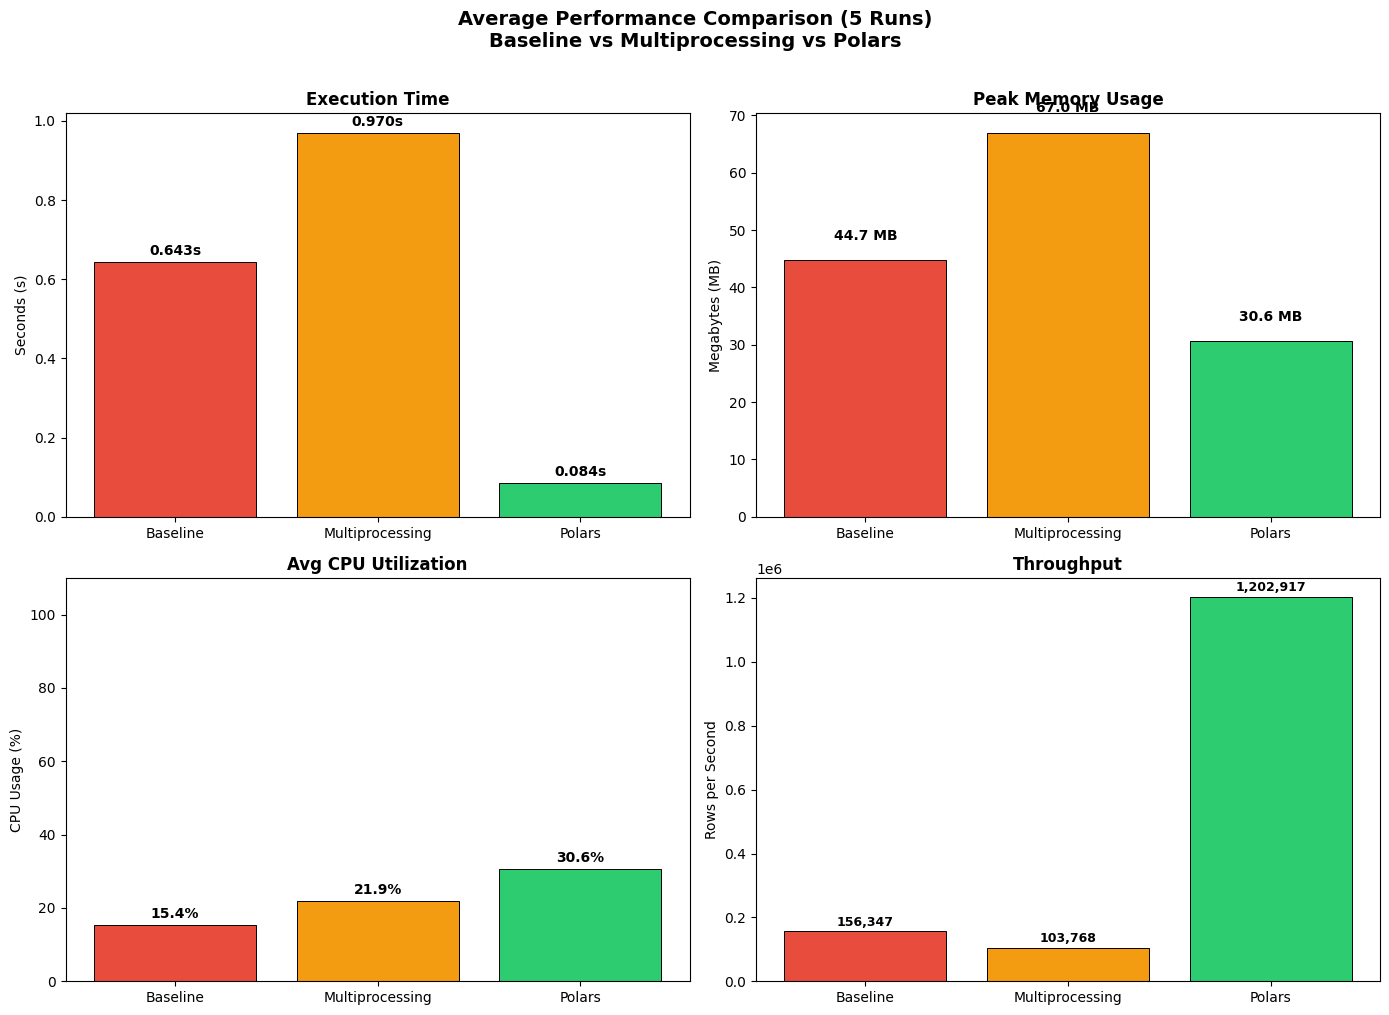

Chart saved as performance_comparison.png


In [12]:
methods_list = list(avg_results.keys())
colors       = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Average Performance Comparison (5 Runs)\nBaseline vs Multiprocessing vs Polars',
             fontsize=14, fontweight='bold', y=1.01)

# ── Chart 1: Execution Time ────────────────────────────────
ax = axes[0, 0]
vals = [avg_results[m]['elapsed_time_s'] for m in methods_list]
errs = [std_results[m]['elapsed_time_s'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Execution Time', fontweight='bold')
ax.set_ylabel('Seconds (s)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.1,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 2: Memory Usage ─────────────────────────────────
ax = axes[0, 1]
vals = [avg_results[m]['peak_memory_mb'] for m in methods_list]
errs = [std_results[m]['peak_memory_mb'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Peak Memory Usage', fontweight='bold')
ax.set_ylabel('Megabytes (MB)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.1,
            f'{val:.1f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 3: CPU Utilization ──────────────────────────────
ax = axes[1, 0]
vals = [avg_results[m]['avg_cpu_pct'] for m in methods_list]
errs = [std_results[m]['avg_cpu_pct'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Avg CPU Utilization', fontweight='bold')
ax.set_ylabel('CPU Usage (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Chart 4: Throughput ───────────────────────────────────
ax = axes[1, 1]
vals = [avg_results[m]['throughput_rps'] for m in methods_list]
errs = [std_results[m]['throughput_rps'] for m in methods_list]
bars = ax.bar(methods_list, vals, color=colors, edgecolor='black', linewidth=0.7)
ax.set_title('Throughput', fontweight='bold')
ax.set_ylabel('Rows per Second')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.05,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as performance_comparison.png")
